<a href="https://colab.research.google.com/github/c-lydia/operating_system/blob/main/os.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Operating System: OS

## Definition

Operating System is a software program that manages a computer's hardware and software resources and provides common services for computer programs. Essentially, it serves as a bridge between users and the computer hardware.

## Funtions of OS

- **Process Management**: The OS handles the creation, scheduling, termination, and synchronization of processes (running programs). It allocates resources to processes and ensures they run efficiently without interfering with each other.
- **Memory Management**: The OS manages the computer's primary memory (RAM). It keeps track of which parts of memory are being used by whom, allocates memory space to processes, and deallocates it when no longer needed.
- **File Management**: This involves organizing and keeping track of files and directories (folders) on storage devices. The OS provides services for creating, deleting, accessing, and protecting files.
- **Device Management**: The OS manages all input/output devices (e.g., keyboard, mouse, printer, disk drives) by allocating them to processes, scheduling their usage, and handling their status.
- **Security Management**: The OS protects system resources and user data from unauthorized access or malicious activities. This includes authentication (passwords), authorization (permissions), and implementing firewalls.
- **Network Management**: The OS handles network communication, allowing different computers to connect and share resources. It manages network interfaces, protocols, and data transmission.
- **Storage Management**: Beyond file management, this refers to managing secondary storage devices (hard drives, SSDs). It includes disk scheduling, free space management, and allocating storage space to files.
- **Command Interpreter System**: This is the component that reads and executes commands given by the user, either through a graphical user interface (GUI) or a command-line interface (CLI).

## Command Line Interface

A terminal is a text-based application that allows you to interact with the operating system using commands instead of a graphical user interface (GUI).

A Command Line Interface (CLI) is a text-based way of interacting with a specific program or tool. Instead of clicking buttons in a GUI, you type commands to get the tool to perform actions.

Example:

``` bash
sudo apt update
sudo apt upgrade
```

## How OS works

### The big picture

These terms describe different things: a **bootloader** starts the operating system, the **kernel** manages the machine, **user space and kernel space** describe protected execution environments, and **middleware** provides reusable services for applications.

| Term | Main purpose | Typical location or phase | Examples |
| --- | --- | --- | --- |
| Firmware | Initialize the platform and begin the boot process | Before the OS starts; some services may remain available afterward | UEFI firmware, legacy BIOS |
| Bootloader | Load a kernel and transfer control to it | Early startup | GRUB, U-Boot |
| Kernel | Manage CPU time, memory, devices, and protected resources | Kernel space while the OS runs | Linux kernel, Windows NT kernel |
| Kernel space | Protected environment for kernel code and data | Privileged part of the running system | Scheduler, memory manager, many device drivers |
| User space | Environment where ordinary programs execute | Restricted processes above the kernel interface | Shells, browsers, servers, libraries, system services |
| Middleware | Provide common application services or process requests | Usually user space, inside an application or in separate services | Message brokers, RPC frameworks, HTTP authentication middleware |

The **kernel is part of an operating system**, not the entire operating system. A usable Linux system also includes libraries, an initialization system, utilities, and other user-space software.

### Runtime architecture


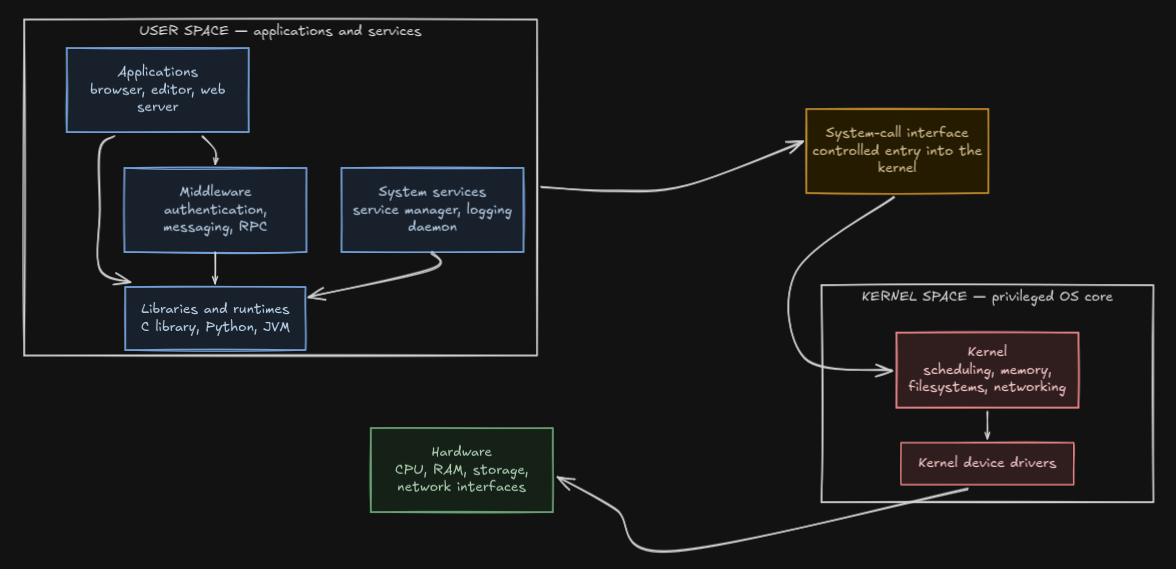

In [8]:
from IPython.display import Image
Image('os_arch.png')

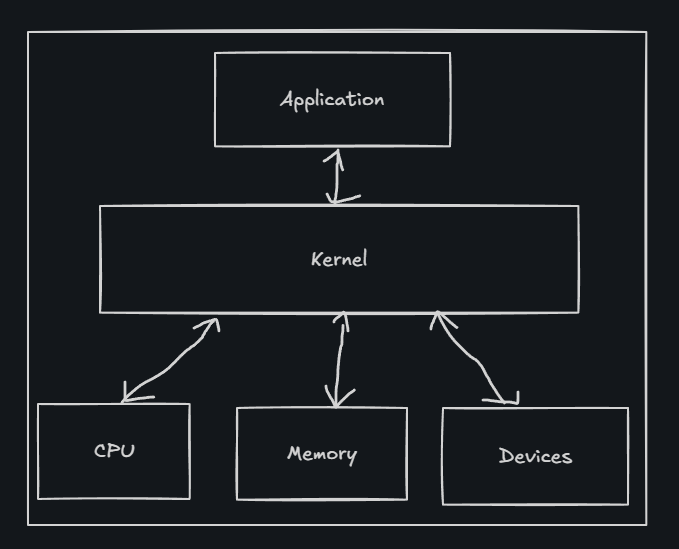

In [ ]:
from IPython.display import Image
Image('kernel.png')

### Kernel: managing shared resources

The kernel is the privileged core of the operating system. It coordinates access to resources so that multiple programs can run without each program directly controlling the entire machine.

| Responsibility | What the kernel does | Everyday example |
| --- | --- | --- |
| CPU scheduling | Chooses which runnable threads execute on each CPU | A browser and music player both make progress |
| Memory management | Maintains virtual-memory mappings and enforces access permissions | One process cannot ordinarily overwrite another process's private memory |
| Process and thread management | Creates, coordinates, and terminates execution contexts | Starting a program or waiting for a child process |
| Filesystems | Provides file abstractions and filesystem operations | Opening a document by its path |
| Device access | Coordinates hardware through drivers | Reading storage or receiving keyboard input |
| Networking | Implements networking mechanisms such as sockets and protocol processing | Sending data over a TCP connection |
| Access control | Checks credentials and permissions for protected operations | Rejecting a file open when the process lacks permission |

A **device driver** understands how to operate a particular device or class of devices. Many Linux drivers execute in kernel space, although some device interactions use user-space drivers or split designs.

Linux uses a **monolithic kernel with loadable modules**: many core services and drivers share the privileged kernel environment. A **microkernel** design keeps a smaller privileged core and places more services in separate user-space processes. The exact boundary depends on the OS design.

### Bootloader: getting the kernel started

A bootloader is a program that prepares and launches an operating-system kernel. Depending on the platform, it can:

- Present a menu of operating systems or kernel versions.
- Load the kernel into memory.
- Load an optional initial RAM filesystem, commonly called an **initramfs** on Linux.
- Provide kernel command-line options and platform information.
- Transfer execution to the kernel's entry point.

The initramfs contains temporary files and early user-space programs that can help locate, unlock, or mount the main root filesystem. It is not the same thing as the kernel.

#### A typical Linux boot sequence


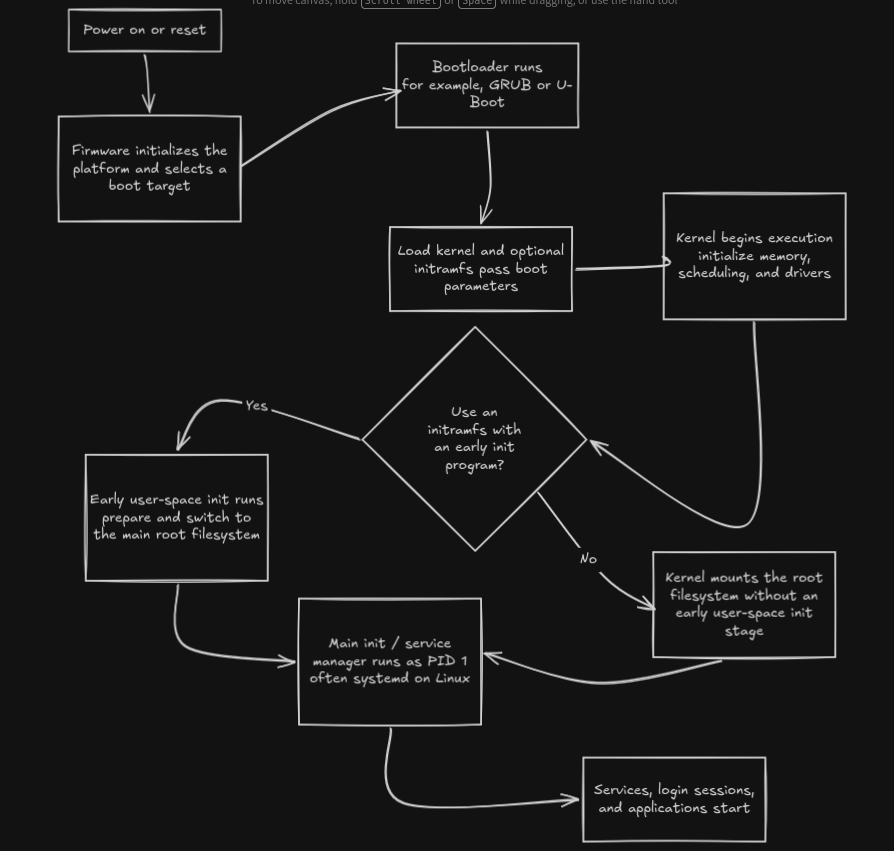

In [7]:
from IPython.display import Image
Image('bootloader.png')


The sequence is **firmware → bootloader → kernel → user-space initialization → services and applications**. With an initramfs, early user space starts before the main root filesystem is ready.

This is a representative sequence, not a universal requirement. Some UEFI systems launch a kernel through its EFI stub without a separate bootloader program. Embedded devices may use several boot stages.

Once control has passed to the kernel, a conventional bootloader does not schedule applications or handle their ongoing file and network requests.

### User space and kernel space

These are protection concepts, not physical places inside the computer.

**User space** contains application code, libraries, runtimes, and most system services. Programs normally execute in **user mode**, where the CPU restricts privileged instructions and memory access.

**Kernel space** contains protected kernel code and data. Kernel code executes in **kernel mode**, with the privileges needed to manage the machine.

Strictly speaking, *space* concerns memory and protection domains, while *mode* concerns the CPU's current execution privilege. The terms are closely related, but they are not interchangeable in every technical discussion.

#### Protection boundaries



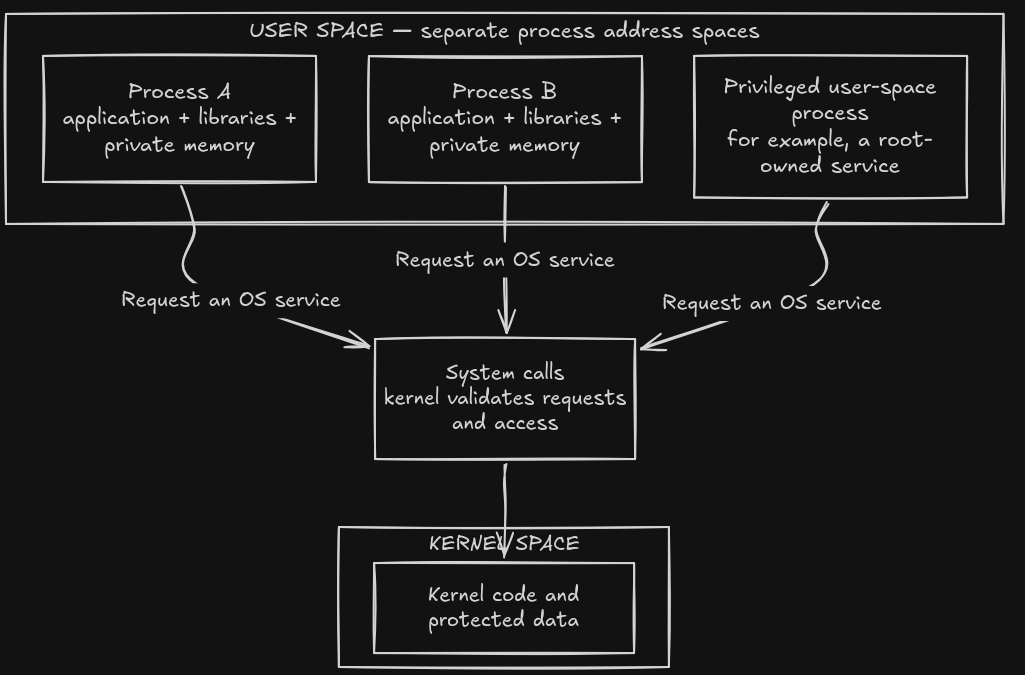

In [6]:
from IPython.display import Image
Image('user_space_kernel_space.png')

Each process normally has its own virtual address space. The same virtual address in two processes need not refer to the same physical memory. Processes can share selected memory through explicit OS mechanisms.

| Question | User space | Kernel space |
| --- | --- | --- |
| What usually runs here? | Applications, daemons, libraries, middleware | Kernel core and many drivers |
| Can code freely access kernel memory? | No; hardware and OS protections restrict access | Kernel code can access protected mappings, subject to architecture and protections |
| How are protected services requested? | Through system calls, often via libraries | Through internal kernel operations and driver interfaces |
| What happens after a serious bug? | Often the affected process crashes; other impact depends on the program | It may compromise or crash the whole system |
| Does administrator status imply kernel mode? | No; administrator programs normally remain user-space processes | Kernel execution is a separate privilege level |

Running `sudo` changes the credentials under which a command executes. It does **not** turn that command into kernel code. The kernel checks those credentials when handling requests; additional security policies and confinement may still apply.

### System calls: crossing the boundary

A **system call** is a defined interface through which a user-space program requests a kernel service. Linux examples include `read`, `write`, `openat`, and `socket`.

A library function and a system call are different things. A library can perform work entirely in user space, issue one system call, or combine several system calls.

For example, `strlen()` can count characters in accessible memory without a system call. A buffered output function may accumulate data in user space and call `write()` only when it flushes its buffer.

#### Example: reading a file

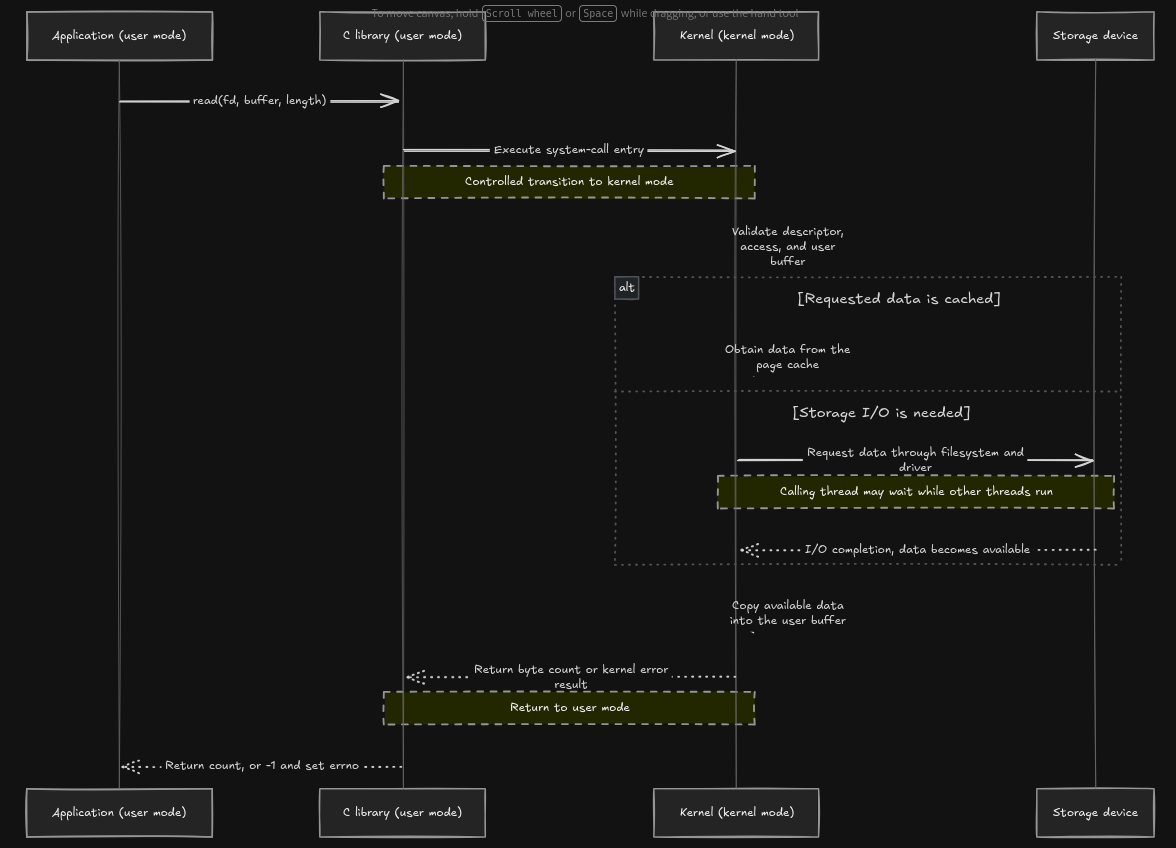

In [9]:
from IPython.display import Image
Image('system_call.png')

This diagram describes a typical buffered read of a regular file. Reads can return fewer bytes than requested, and a return value of zero indicates end of file in this context. Other I/O methods, such as memory-mapped files, follow different paths.

A system call causes a **privilege-mode transition**, but it does not necessarily cause a **thread context switch**. The same calling thread can enter the kernel and return. If it must wait for I/O, the scheduler may run another thread.

The kernel can also gain control through **interrupts** from hardware and **exceptions** such as page faults; system calls are not the only entry mechanism.

### Middleware: reusable services around applications

Middleware is software that supplies shared capabilities or helps application components communicate. It usually runs in user space and relies on the OS for memory, scheduling, files, and networking.

The term is used in two common ways:

| Meaning | What it does | Examples |
| --- | --- | --- |
| Application infrastructure | Supports communication and coordination between applications or services | Message brokers, RPC frameworks, service integration software |
| Request-processing middleware | Wraps an application's request handler with reusable behavior | Authentication, logging, rate limiting, CORS handling |

Middleware may be a library loaded into an application's process, a separate local process, or a service on another machine. It is an architectural role, not a CPU privilege level.

#### Example: an HTTP middleware pipeline


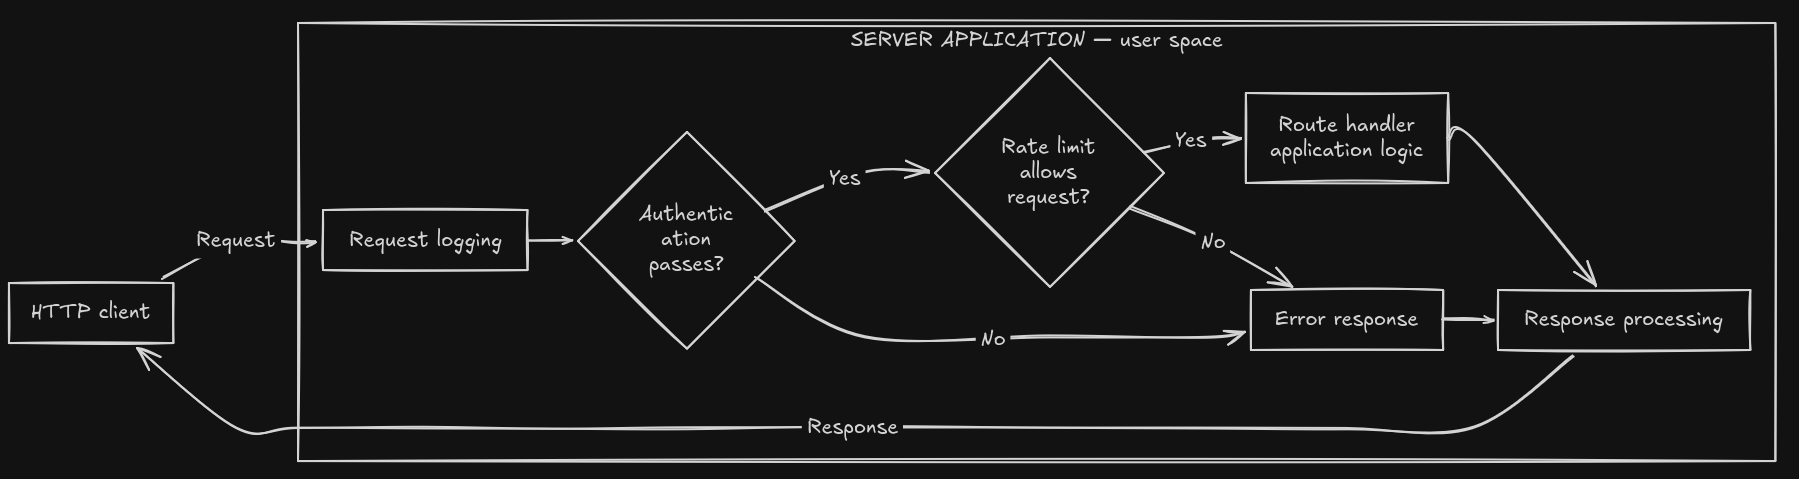

In [13]:
from IPython.display import Image
Image('ex_http_middleware.png')

This is a logical application flow; the underlying sockets and kernel networking are omitted. Middleware order matters. For example, logging placed before authentication can record rejected requests, and a rate limiter placed after authentication can use the authenticated identity.

Different frameworks organize response handling differently. Some unwind through the middleware chain in reverse order. Middleware can also stop a request early without invoking the route handler.

#### Example: messaging between services


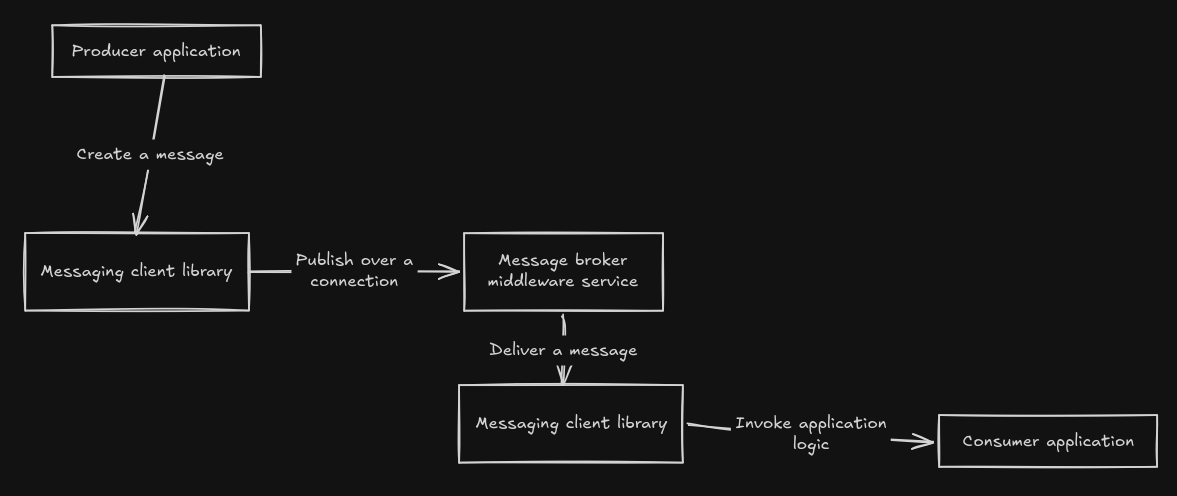

In [15]:
from IPython.display import Image
Image('service_comm.png')

The broker can provide queues, routing, acknowledgments, or persistence, depending on the product and configuration. The producer, broker, and consumer run as user-space programs, potentially on different computers. Their kernels handle the underlying network and storage operations.

### Putting everything together

Imagine starting a Linux computer and opening a web application hosted on it:

1. **Firmware** initializes the platform and selects a boot target.
2. The **bootloader** loads the kernel and any required early boot files, then transfers control.
3. The **kernel** initializes core facilities and starts the first user-space process.
4. Early initialization prepares the system; the main **init/service manager** starts services, including the web server.
5. The web server runs in **user space**. Its runtime and libraries use sockets to receive requests through the kernel.
6. **Middleware** logs the request, checks authentication, or applies other common behavior.
7. The application's handler performs its task. File, network, or other protected operations enter **kernel space** through system calls when needed.
8. The kernel coordinates the necessary work, and the application sends its response.

The kernel remains active throughout the session. Middleware handles application concerns during runtime. The bootloader's normal work took place during startup.

### Common mix-ups

| Misunderstanding | Correction |
| --- | --- |
| “Middleware must sit between every application and the kernel.” | Applications can call OS interfaces without middleware. Middleware provides application services, and its placement varies. |
| “User space means software with a graphical interface.” | Command-line tools, background daemons, databases, and server middleware also run in user space. |
| “A root process runs in kernel space.” | Root is an OS identity with elevated permissions; its programs normally execute in user mode. |
| “The bootloader keeps managing the computer.” | Its main role is to load and start the kernel. The kernel manages the running system. |
| “Every library function enters the kernel.” | Many library functions do all their work in user space. |
| “Every system call switches to another process.” | Entering kernel mode does not by itself require switching threads or processes. |
| “Kernel space is a separate RAM chip.” | It is a protected memory/execution environment, not separate physical hardware. |
| “All operating systems place all drivers in the kernel.” | Driver placement varies; user-space and split driver designs also exist. |

### Quick glossary

- **Process:** A running program instance with resources such as an address space and open file descriptors.
- **Thread:** An execution stream scheduled by the OS; threads in one process share many resources.
- **Daemon:** A background service, usually running in user space.
- **Runtime:** Software that supports program execution, such as the JVM or a Python interpreter.
- **IPC:** Inter-process communication, such as pipes, shared memory, or local sockets.
- **RPC:** Remote procedure call; a framework presents communication with another component in a function-call-like form, with possible latency and communication failures.
- **Virtual memory:** Address translation and protection that give processes their own memory views.
- **Interrupt:** An event, often from hardware, that causes the CPU to transfer control to a handler.
- **Page fault:** An exception triggered when a memory access needs OS handling; it may be a normal demand-paging event or an invalid access.
- **Context switch:** Saving one execution context and restoring another so a different thread or task can run.
- **PID 1:** The first process in a Linux PID namespace; in the initial namespace, it normally performs system initialization or becomes the main init process.

## File System

File system is a way in which files are named and placed in the computer for storage and retreival.

### Layers of file system

- **Logical file system:** responsible for interaction with user applications
- **VFS (Virtual File System):** is the interface between the kernel and a concrete file system
- **Physical file system:** defines how blocks are being read and written, handles memory management and buffering

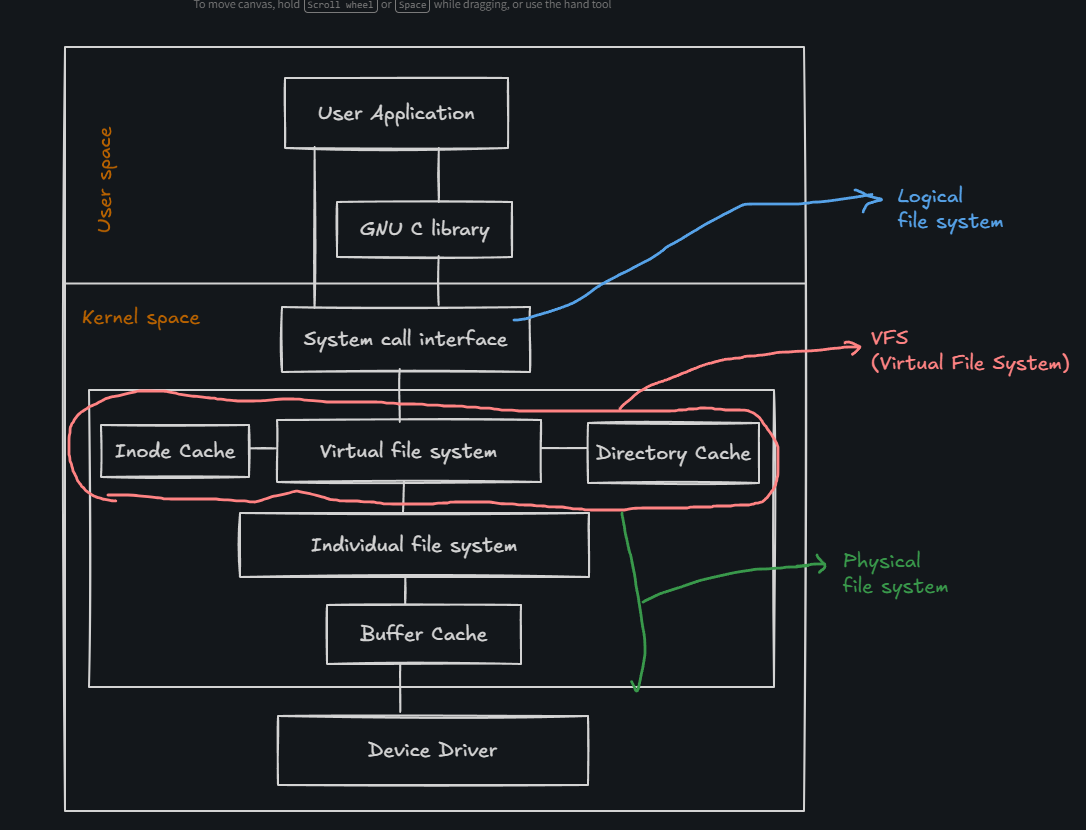

In [ ]:
from IPython.display import Image
Image('file_system.png')

### Directory Structure

- `bin/` (binaries): holds all th eprogramss that live in our machine
- `boot/`: contains all the files required by the kernal at the time of boot and ou bootloader also resides in this directory
- `sbin/`: contains system binaries that are required for the system administration
- `dev/`: contains all devices and each device is represented with a file (only the devices attcahed to the system)
- `etc/` (edit-to-configure): stores all your configuration for software used by the system
- `lib/` (libraries): contains all the libraries that are required to boot the system and used by different applications to perform different functions
- `media/` and `mnt/`: contains the mounted drives
- `opt/`: contains all the manually installed software usually from the vendor
- `proc/`: contains information of the hardware and running processes on the system
- `root/`: considered as `home/` for the root user and only accessed by user with root permission
- `run/`: temporary file system (tmpfs); will be wiped when the systme is rebooted or shutdown and contains programs required early in the boot procedure
- `srv/`: stores all files that are accessed by external users when using ftp server
- `sys/` (system): contains files that ibteract with the kernel
- `tmp/` (temporary): stores files used by applications sessions
- `usr/`: contains shareable, read-only files, includong executables and libraries, man filesm and other types of documentation
- `var/`: contains files that are expected to grow
- `home/`: storage for user files

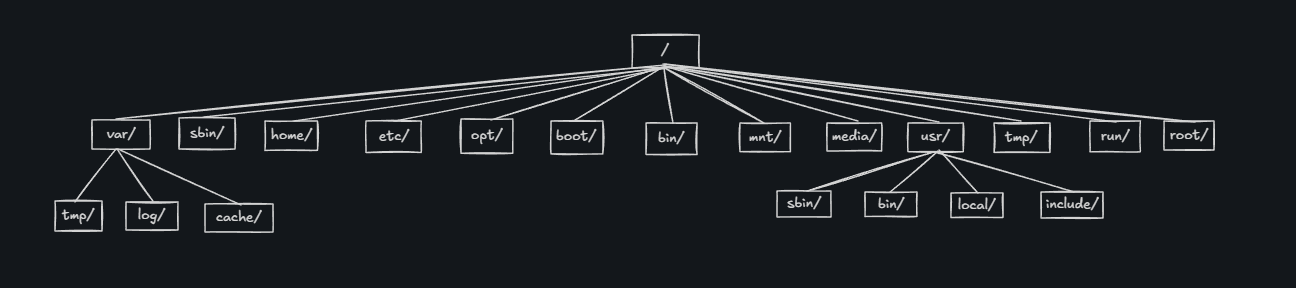

In [ ]:
from IPython.display import Image
Image('dir.png')

### Navigation

- `pwd`: where you are
- `ls`: list directory contents
  - `-l`: detailed view with permissions, owner, and timestamps
  - `-a`: shows hidden files
- `cd`: change directory
  - `~`: moves to `/home`
  - `..`: moves one directory up
  - `-`: switches to last directory
- `find`: search for files
- `locate`: quickly find files

> Note: before using `locate`, run `sudo updatedb` first to refresh it because `locate` works like index searching

### File Operations

- `touch`: creats an empty file
- `cat`: outputs file content
- `cp`: copies files or folders
- `mv`: moves files or renames file
- `rm`: remove file permanently
- `mkdir`: make directory

``` bash
# syntax

touch [filename]
cat [filename]
cp [filename]
cp [filename] [destination] # copy file to another destination
mv [filename] [destination]
mv [filename] [new_filename] # if rename
cp -r [dirname] [destination] # for directories
mv -r [dirname] [destination]
rm [filename]
rm -r [dirname]
rm -rf [dirname] # f = force, r = recursive
mkdir -p [dirname]
```

### Permission




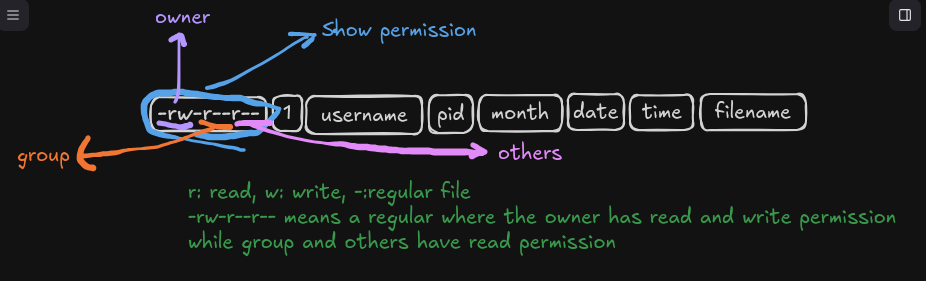

In [6]:
from IPython.display import Image
Image('permission_structure.png')

#### Structure

- File types:
  - `-`: regular file
  - `d`: directory
  - `l`: symbiolic link
- Permission representation goes in this order: `owner, group, others`
- Each set uses:
  - `r`: read
  - `w`: write
  - `x`: execute
- A `-` indicates that permission is not granted

#### Numeric representation

- `4`: read
- `2`: write
- `1`: execute

For each set of permission, these values are summed

- `7 = 4 + 2` -> read, write, and execute
- `6 = 4 + 2` -> read and write
- `5 = 4 + 1` -> read and execute
- `4` -> read

`-rw-r--r-- = 644`

#### permission modification

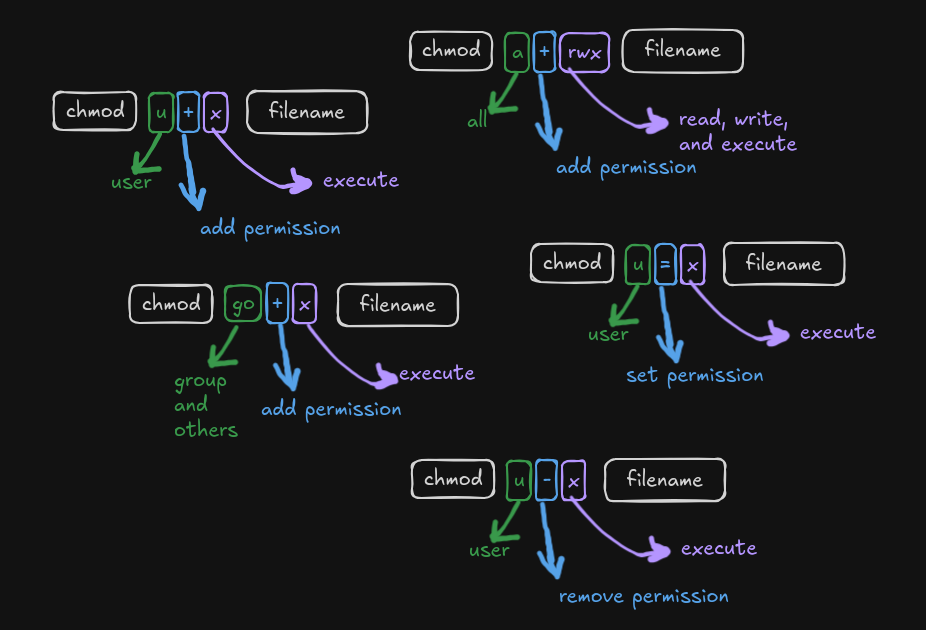

In [7]:
from IPython.display import Image
Image('permission_symbolic.png')

Syntax:

``` bash
chmod [reference][operator][permission] [filename]
```

- `reference`: user, group, others
- `operator`: add, remove, set
- `permission`: read, write, execute

For Numeric mode, use the summed up permission

``` bash
chmod 755 file.txt
```

- `chown`: change ownership

syntax:

``` bash
chown [options][owner]:[group] [filename]
```

Example:

``` bash
chown user2:group1 example.txt
```

## Environment Variables

Environment variables are dynamic values that define the behavior of system processes and applications.

### Types

- **System:** available for all susers, sets by system admin
- **User:** defined per user
- **Shell:** exists onyl within running shell session

Some common environment variables:

- `PATH`

``` bash
echo $PATH
export PATH=/usr/local/bin:$PATH
```

- `HOME`

``` bash
echo $HOME
```

- `USER`

stores username of the logged-in users

``` bash
echo $USER
```

- `SHELL`: defines default shell of the user
- `EDITOR`: defines default text editor
- `LANG`: sets system language

### Operations

- View environment variables

``` bash
printenv
env
set | less
```

- Set environment variables

``` bash
export MY_VAR="Hello World"
echo $MY_VAR
```

- Set environment variables permenanently

``` bash
echo 'export MY_VAR="Hello World" >> ~/.bashrc
source ~/.bashrc
```

- Unset environment variables

``` bash
unset MY_VAR
echo $MY_VAR
```

## Package Management

Package is a compressed archive containing all files necessary for specific software to run

### Dependencies

The diversity i=of Linux distribution

## Resources

- **Operating Systems Concepts**: A classic textbook for understanding OS principles.
  - [Operating System Concepts (Avi Silberschatz, Peter Baer Galvin, Greg Gagne)](https://www.os-book.com/)

- **Linux Command Line Basics**: Tutorials and guides for mastering the command line.
  - [The Linux Command Line (William Shotts)](http://linuxcommand.org/tlcl.php)
  - [Command Line Crash Course](https://ryanstutorials.net/linuxtutorial/commandline.php)

- **File Systems Explained**: Resources to delve deeper into how file systems work.
  - [How a File System Works](https://www.youtube.com/watch?v=b2FjHh2p66g) (Video by Computerphile)
  - [Introduction to File Systems](https://www.geeksforgeeks.org/introduction-of-file-system/)


In [1]:
# The original cell to print the markdown content is no longer needed after integration.

# Bootloaders, Kernels, Middleware, User Space, and Kernel Space

A practical guide to what these terms mean, how they connect, and what happens from pressing the power button to running an application.

The examples use a typical Linux system. Other operating systems share many of these ideas, but their boot processes and internal designs differ.

> **Diagrams:** This file uses Mermaid. Open it in a Markdown viewer that supports Mermaid to see the rendered diagrams. Each diagram also has a short explanation in ordinary text.

## 1. The big picture

These terms describe different things: a **bootloader** starts the operating system, the **kernel** manages the machine, **user space and kernel space** describe protected execution environments, and **middleware** provides reusable services for applications.

| Term | Main purpose | Typical location or phase | Examples |
| --- | --- | --- | --- |
| Firmware | Initialize the platform and begin the boot process | Before the OS starts; some s

In [ ]:
# The original cell to print the markdown content is no longer needed after integration.